Using device: cuda
PINN_PNP(
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
  (activation): Tanh()
)
Starting PINN training...
Epoch     0 | Total: 8.521e+01 | P: 1.46e-02 | NP: 2.02e-03,1.99e-03 | B: 5.81e+00,2.71e+00
Epoch  2000 | Total: 6.006e-05 | P: 3.21e-05 | NP: 1.31e-05,1.49e-05 | B: 1.87e-09,1.67e-10
Epoch  4000 | Total: 3.859e-05 | P: 1.34e-05 | NP: 1.20e-05,5.19e-06 | B: 4.80e-07,3.14e-07
Epoch  6000 | Total: 5.859e-03 | P: 1.48e-04 | NP: 6.66e-05,5.20e-05 | B: 2.14e-04,3.45e-04
Epoch  8000 | Total: 9.741e-05 | P: 9.69e-06 | NP: 4.29e-06,3.87e-06 | B: 4.16e-06,3.80e-06
Epoch 10000 | Total: 5.944e-06 | P: 1.14e-06 | NP: 1.30e-06,2.05e-06 | B: 8.02e-08,6.53e-08
Epoch 12000 | Total: 3.414e-04 | P: 2.14e-05 | NP: 3.97e-06,3.51e-06 | B: 1.52e-05,1.60e-05
Epoch 14000 | Total: 6.105e-06 | P: 5.46e-07 | NP: 4.67e-07

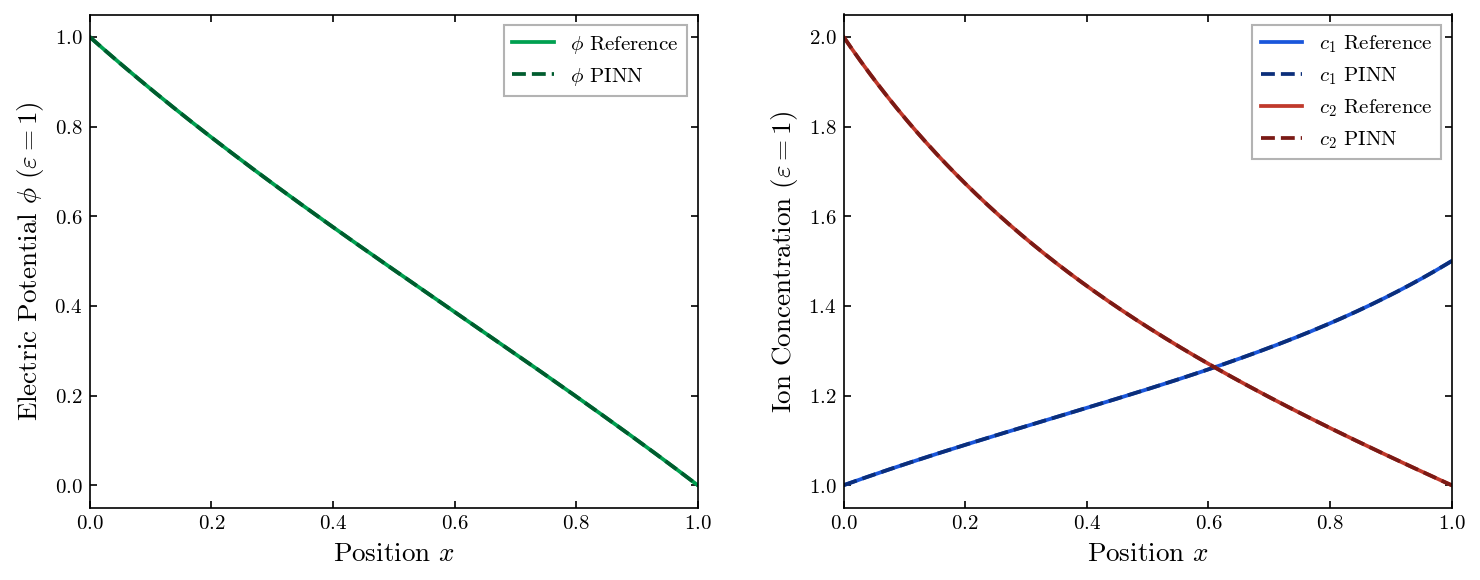

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from scipy.integrate import solve_bvp as scipy_bvp

# ============================================================
# Plot style: Computer Modern font, matching TikZ diagram
# ============================================================
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'axes.formatter.use_mathtext': True,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '0.7',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Colors matching the TikZ diagram palette
BLUE   = '#1a56db'
RED    = '#c0392b'
GREEN  = '#00a050'
BLUE_D = '#0b2e7a'   # darker blue for PINN dashed
RED_D  = '#7a1a15'   # darker red for PINN dashed
GREEN_D= '#005c2e'   # darker green for PINN dashed

# ============================================================
# Device configuration
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================
# Problem parameters
# ============================================================
V = 1.0
L1, L2 = 1.0, 2.0
R1, R2 = 1.5, 1.0
epsilon = 1

# ============================================================
# 1. Neural network
# ============================================================
class PINN_PNP(nn.Module):
    def __init__(self, layers=[1, 128, 128, 128, 3]):
        super(PINN_PNP, self).__init__()
        self.linears = nn.ModuleList()
        for i in range(len(layers)-1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = nn.Tanh()

    def forward(self, x):
        u = x
        for i, lin in enumerate(self.linears[:-1]):
            u = self.activation(lin(u))
        u = self.linears[-1](u)
        c1  = u[:, 0:1]
        c2  = u[:, 1:2]
        phi = u[:, 2:3]
        return c1, c2, phi

model = PINN_PNP().to(device)
print(model)

# ============================================================
# 2. Collocation points
# ============================================================
N_in = 200
N_b  = 50

x_in    = torch.linspace(0, 1, N_in, requires_grad=True).view(-1, 1).to(device)
x_left  = torch.zeros(N_b, 1, requires_grad=True).to(device)
x_right = torch.ones(N_b, 1, requires_grad=True).to(device)

# ============================================================
# 3. Loss function
# ============================================================
def compute_loss():
    losses = {}
    # Boundary
    c1_l, c2_l, phi_l = model(x_left)
    loss_b_left = (torch.mean((phi_l - V)**2) +
                   torch.mean((c1_l - L1)**2) +
                   torch.mean((c2_l - L2)**2))
    c1_r, c2_r, phi_r = model(x_right)
    loss_b_right = (torch.mean((phi_r - 0.0)**2) +
                    torch.mean((c1_r - R1)**2) +
                    torch.mean((c2_r - R2)**2))
    losses['b_left']  = loss_b_left
    losses['b_right'] = loss_b_right

    # Interior PDE residuals
    c1_pred, c2_pred, phi_pred = model(x_in)
    grad_phi  = grad(phi_pred, x_in, grad_outputs=torch.ones_like(phi_pred), create_graph=True)[0]
    grad_c1   = grad(c1_pred,  x_in, grad_outputs=torch.ones_like(c1_pred),  create_graph=True)[0]
    grad_c2   = grad(c2_pred,  x_in, grad_outputs=torch.ones_like(c2_pred),  create_graph=True)[0]
    grad2_phi = grad(grad_phi, x_in, grad_outputs=torch.ones_like(grad_phi), create_graph=True)[0]

    # Poisson: ε² φ'' = -(c1 - c2)
    residual_poisson = epsilon**2 * grad2_phi + (c1_pred - c2_pred)
    loss_p = torch.mean(residual_poisson**2)
    losses['p'] = loss_p

    # Nernst–Planck: d/dx(dc_k/dx + α_k c_k dφ/dx) = 0  =>  flux = const  =>  d(flux)/dx = 0
    residual_np1 = grad_c1 + c1_pred * grad_phi
    residual_np2 = grad_c2 - c2_pred * grad_phi
    grad_res1 = grad(residual_np1, x_in, grad_outputs=torch.ones_like(residual_np1), create_graph=True)[0]
    grad_res2 = grad(residual_np2, x_in, grad_outputs=torch.ones_like(residual_np2), create_graph=True)[0]
    loss_np1 = torch.mean(grad_res1**2)
    loss_np2 = torch.mean(grad_res2**2)
    losses['np1'] = loss_np1
    losses['np2'] = loss_np2

    loss_total = (1.0 * loss_p + 1.0 * loss_np1 + 1.0 * loss_np2 +
                  10.0 * loss_b_left + 10.0 * loss_b_right)
    losses['total'] = loss_total
    return losses

# ============================================================
# 4. Training
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9)
epochs = 50000
loss_history = {'total': [], 'p': [], 'np1': [], 'np2': [], 'b_left': [], 'b_right': []}

print("Starting PINN training...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    losses = compute_loss()
    loss = losses['total']
    loss.backward()
    optimizer.step()
    scheduler.step()

    for key in loss_history:
        loss_history[key].append(losses[key].item())

    if epoch % 2000 == 0:
        print(f"Epoch {epoch:5d} | Total: {loss.item():.3e} | "
              f"P: {losses['p'].item():.2e} | NP: {losses['np1'].item():.2e},{losses['np2'].item():.2e} | "
              f"B: {losses['b_left'].item():.2e},{losses['b_right'].item():.2e}")

# ============================================================
# 5. Reference solution via solve_bvp
# ============================================================
def compute_bvp_reference(eps, V, L1, L2, R1, R2, n_init=5000):
    """Solve the full PNP system with scipy solve_bvp."""
    c_L = np.sqrt(L1 * L2)
    c_R = np.sqrt(R1 * R2)
    phi_L = V + 0.5 * np.log(L1 / L2)
    phi_R = 0.5 * np.log(R1 / R2)
    M  = 2 * c_L
    T0 = 2 * (c_L - c_R)
    if abs(T0) > 1e-12:
        I0 = T0 * (phi_R - phi_L) / np.log(c_R / c_L)
    else:
        I0 = 2 * c_L * (phi_R - phi_L)
    J10 = (I0 + T0) / 2
    J20 = (T0 - I0) / 2

    l_param = (L2**0.25 - L1**0.25) / (L2**0.25 + L1**0.25)
    r_param = (R2**0.25 - R1**0.25) / (R2**0.25 + R1**0.25)
    N = 2 * c_R

    x_init = np.linspace(0, 1, n_init)
    c0 = c_L - T0 * x_init / 2
    if abs(T0) > 1e-12:
        phi0 = phi_L - (I0 / T0) * np.log(M) + (I0 / T0) * np.log(np.abs(M - T0 * x_init))
    else:
        phi0 = phi_L + I0 * x_init / (2 * c_L)

    xi  = x_init / eps
    u_L = l_param * np.exp(-np.sqrt(M) * np.minimum(xi, 100))
    rpL = (1 + u_L) / np.maximum(np.abs(1 - u_L), 1e-15)

    eta = (x_init - 1) / eps
    u_R = r_param * np.exp(np.sqrt(N) * np.maximum(eta, -100))
    rpR = (1 + u_R) / np.maximum(np.abs(1 - u_R), 1e-15)

    phi_guess = phi0 + 2 * np.log(np.abs(rpL)) + 2 * np.log(np.abs(rpR))
    c1_guess  = np.maximum(c0 + (c_L / rpL**2 - c_L) + (c_R / rpR**2 - c_R), 0.01)
    c2_guess  = np.maximum(c0 + (c_L * rpL**2 - c_L) + (c_R * rpR**2 - c_R), 0.01)

    y0 = np.zeros((6, n_init))
    y0[0] = phi_guess
    y0[1] = np.gradient(phi_guess, x_init)
    y0[2] = c1_guess
    y0[3] = c2_guess
    y0[4] = J10 * np.ones(n_init)
    y0[5] = J20 * np.ones(n_init)

    def pnp_ode(x, y):
        phi, E, c1, c2, J1, J2 = y
        return np.vstack([E, -(c1 - c2) / eps**2,
                          -c1 * E - J1, c2 * E - J2,
                          np.zeros_like(x), np.zeros_like(x)])

    def pnp_bc(ya, yb):
        return np.array([ya[0] - V, yb[0],
                         ya[2] - L1, yb[2] - R1,
                         ya[3] - L2, yb[3] - R2])

    sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
    assert sol.success, f"solve_bvp failed: {sol.message}"
    return sol

print("\nSolving reference BVP...")
sol_ref = compute_bvp_reference(epsilon, V, L1, L2, R1, R2)
print("BVP solved successfully.")

# ============================================================
# 6. Evaluation & Plotting
# ============================================================
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(0, 1, 500).view(-1, 1).to(device)
    c1_plot, c2_plot, phi_plot = model(x_plot)
    x_np   = x_plot.cpu().numpy().flatten()
    c1_np  = c1_plot.cpu().numpy().flatten()
    c2_np  = c2_plot.cpu().numpy().flatten()
    phi_np = phi_plot.cpu().numpy().flatten()

# Evaluate reference on the same x grid
y_ref  = sol_ref.sol(x_np)
phi_ref, c1_ref, c2_ref = y_ref[0], y_ref[2], y_ref[3]

# ============================================================
# 6a. Error metrics
# ============================================================
for name, u_nn, u_ex in [('phi', phi_np, phi_ref),
                          ('c1',  c1_np,  c1_ref),
                          ('c2',  c2_np,  c2_ref)]:
    err = np.abs(u_nn - u_ex)
    norm_ex  = np.sqrt(np.trapz(u_ex**2, x_np))
    norm_err = np.sqrt(np.trapz(err**2, x_np))
    rel_L2 = norm_err / max(norm_ex, 1e-16)
    Linf   = np.max(err)
    print(f"  {name:>3s}:  relative L2 = {rel_L2:.4e},  L_inf = {Linf:.4e}")
# ============================================================
# 6. Plotting
# ============================================================
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(0, 1, 500).view(-1, 1).to(device)
    c1_plot, c2_plot, phi_plot = model(x_plot)
    x_np   = x_plot.cpu().numpy().flatten()
    c1_np  = c1_plot.cpu().numpy().flatten()
    c2_np  = c2_plot.cpu().numpy().flatten()
    phi_np = phi_plot.cpu().numpy().flatten()

# Evaluate reference on the same x grid
y_ref  = sol_ref.sol(x_np)
phi_ref, c1_ref, c2_ref = y_ref[0], y_ref[2], y_ref[3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Left panel: Ion Concentrations ---
ax1.plot(x_np, phi_ref, color=GREEN,  linestyle='-',  label='$\\phi$ Reference')
ax1.plot(x_np, phi_np,  color=GREEN_D, linestyle='--', label='$\\phi$ PINN')
ax1.set_xlabel('Position $x$')
ax1.set_ylabel('Electric Potential $\\phi$ ($\\varepsilon=1$)')
ax1.set_xlim(0, 1)
ax1.legend(loc='best')

# --- Right panel: Electric Potential ---
ax2.plot(x_np, c1_ref, color=BLUE, linestyle='-',  label='$c_1$ Reference')
ax2.plot(x_np, c1_np,  color=BLUE_D, linestyle='--', label='$c_1$ PINN')
ax2.plot(x_np, c2_ref, color=RED,  linestyle='-',  label='$c_2$ Reference')
ax2.plot(x_np, c2_np,  color=RED_D, linestyle='--', label='$c_2$ PINN')
ax2.set_xlabel('Position $x$')
ax2.set_ylabel('Ion Concentration ($\\varepsilon=1$)')
ax2.set_xlim(0, 1)
ax2.legend(loc='best')

plt.tight_layout(w_pad=2.5)
plt.show()

Using device: cuda
PINN_PNP(
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
  (activation): Tanh()
)
Starting PINN training...
Epoch     0 | Total: 7.766e+01 | P: 9.90e-03 | NP: 7.04e-03,1.31e-03 | B: 5.44e+00,2.32e+00
Epoch  2000 | Total: 2.313e-01 | P: 5.84e-02 | NP: 2.80e-02,1.31e-01 | B: 8.56e-04,5.63e-04
Epoch  4000 | Total: 3.319e-02 | P: 3.14e-02 | NP: 9.18e-04,2.03e-04 | B: 1.41e-05,4.85e-05
Epoch  6000 | Total: 2.962e-02 | P: 1.95e-02 | NP: 7.38e-03,1.01e-03 | B: 1.36e-04,3.32e-05
Epoch  8000 | Total: 1.280e-02 | P: 1.24e-02 | NP: 1.34e-04,1.19e-04 | B: 7.72e-06,4.50e-06
Epoch 10000 | Total: 9.037e-03 | P: 8.73e-03 | NP: 9.85e-05,1.17e-04 | B: 5.52e-06,3.77e-06
Epoch 12000 | Total: 7.980e-03 | P: 5.80e-03 | NP: 3.03e-04,1.59e-03 | B: 1.85e-05,1.04e-05
Epoch 14000 | Total: 4.227e-03 | P: 4.14e-03 | NP: 3.25e-05

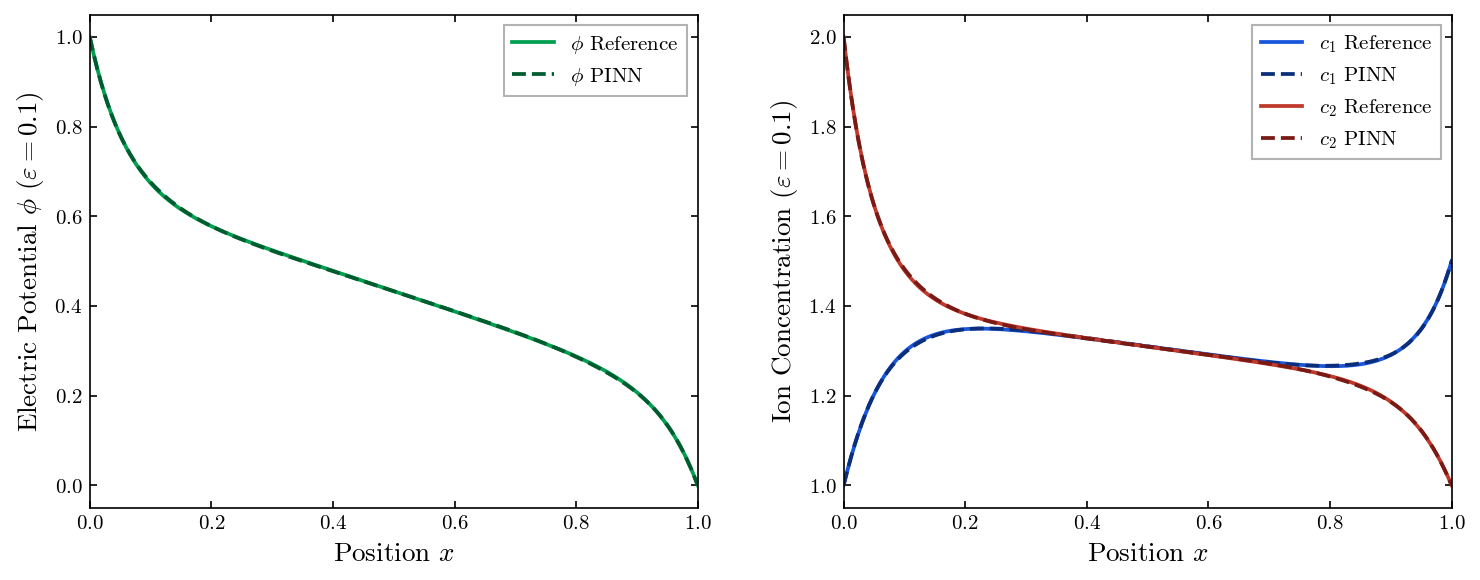

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from scipy.integrate import solve_bvp as scipy_bvp

# ============================================================
# Plot style: Computer Modern font, matching TikZ diagram
# ============================================================
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'axes.formatter.use_mathtext': True,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '0.7',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Colors matching the TikZ diagram palette
BLUE   = '#1a56db'
RED    = '#c0392b'
GREEN  = '#00a050'
BLUE_D = '#0b2e7a'   # darker blue for PINN dashed
RED_D  = '#7a1a15'   # darker red for PINN dashed
GREEN_D= '#005c2e'   # darker green for PINN dashed

# ============================================================
# Device configuration
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================
# Problem parameters
# ============================================================
V = 1.0
L1, L2 = 1.0, 2.0
R1, R2 = 1.5, 1.0
epsilon = 0.1

# ============================================================
# 1. Neural network
# ============================================================
class PINN_PNP(nn.Module):
    def __init__(self, layers=[1, 128, 128, 128, 3]):
        super(PINN_PNP, self).__init__()
        self.linears = nn.ModuleList()
        for i in range(len(layers)-1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = nn.Tanh()

    def forward(self, x):
        u = x
        for i, lin in enumerate(self.linears[:-1]):
            u = self.activation(lin(u))
        u = self.linears[-1](u)
        c1  = u[:, 0:1]
        c2  = u[:, 1:2]
        phi = u[:, 2:3]
        return c1, c2, phi

model = PINN_PNP().to(device)
print(model)

# ============================================================
# 2. Collocation points
# ============================================================
N_in = 200
N_b  = 50

x_in    = torch.linspace(0, 1, N_in, requires_grad=True).view(-1, 1).to(device)
x_left  = torch.zeros(N_b, 1, requires_grad=True).to(device)
x_right = torch.ones(N_b, 1, requires_grad=True).to(device)

# ============================================================
# 3. Loss function
# ============================================================
def compute_loss():
    losses = {}
    # Boundary
    c1_l, c2_l, phi_l = model(x_left)
    loss_b_left = (torch.mean((phi_l - V)**2) +
                   torch.mean((c1_l - L1)**2) +
                   torch.mean((c2_l - L2)**2))
    c1_r, c2_r, phi_r = model(x_right)
    loss_b_right = (torch.mean((phi_r - 0.0)**2) +
                    torch.mean((c1_r - R1)**2) +
                    torch.mean((c2_r - R2)**2))
    losses['b_left']  = loss_b_left
    losses['b_right'] = loss_b_right

    # Interior PDE residuals
    c1_pred, c2_pred, phi_pred = model(x_in)
    grad_phi  = grad(phi_pred, x_in, grad_outputs=torch.ones_like(phi_pred), create_graph=True)[0]
    grad_c1   = grad(c1_pred,  x_in, grad_outputs=torch.ones_like(c1_pred),  create_graph=True)[0]
    grad_c2   = grad(c2_pred,  x_in, grad_outputs=torch.ones_like(c2_pred),  create_graph=True)[0]
    grad2_phi = grad(grad_phi, x_in, grad_outputs=torch.ones_like(grad_phi), create_graph=True)[0]

    # Poisson: ε² φ'' = -(c1 - c2)
    residual_poisson = epsilon**2 * grad2_phi + (c1_pred - c2_pred)
    loss_p = torch.mean(residual_poisson**2)
    losses['p'] = loss_p

    # Nernst–Planck: d/dx(dc_k/dx + α_k c_k dφ/dx) = 0  =>  flux = const  =>  d(flux)/dx = 0
    residual_np1 = grad_c1 + c1_pred * grad_phi
    residual_np2 = grad_c2 - c2_pred * grad_phi
    grad_res1 = grad(residual_np1, x_in, grad_outputs=torch.ones_like(residual_np1), create_graph=True)[0]
    grad_res2 = grad(residual_np2, x_in, grad_outputs=torch.ones_like(residual_np2), create_graph=True)[0]
    loss_np1 = torch.mean(grad_res1**2)
    loss_np2 = torch.mean(grad_res2**2)
    losses['np1'] = loss_np1
    losses['np2'] = loss_np2

    loss_total = (1.0 * loss_p + 1.0 * loss_np1 + 1.0 * loss_np2 +
                  10.0 * loss_b_left + 10.0 * loss_b_right)
    losses['total'] = loss_total
    return losses

# ============================================================
# 4. Training
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9)
epochs = 50000
loss_history = {'total': [], 'p': [], 'np1': [], 'np2': [], 'b_left': [], 'b_right': []}

print("Starting PINN training...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    losses = compute_loss()
    loss = losses['total']
    loss.backward()
    optimizer.step()
    scheduler.step()

    for key in loss_history:
        loss_history[key].append(losses[key].item())

    if epoch % 2000 == 0:
        print(f"Epoch {epoch:5d} | Total: {loss.item():.3e} | "
              f"P: {losses['p'].item():.2e} | NP: {losses['np1'].item():.2e},{losses['np2'].item():.2e} | "
              f"B: {losses['b_left'].item():.2e},{losses['b_right'].item():.2e}")

# ============================================================
# 5. Reference solution via solve_bvp
# ============================================================
def compute_bvp_reference(eps, V, L1, L2, R1, R2, n_init=5000):
    """Solve the full PNP system with scipy solve_bvp."""
    c_L = np.sqrt(L1 * L2)
    c_R = np.sqrt(R1 * R2)
    phi_L = V + 0.5 * np.log(L1 / L2)
    phi_R = 0.5 * np.log(R1 / R2)
    M  = 2 * c_L
    T0 = 2 * (c_L - c_R)
    if abs(T0) > 1e-12:
        I0 = T0 * (phi_R - phi_L) / np.log(c_R / c_L)
    else:
        I0 = 2 * c_L * (phi_R - phi_L)
    J10 = (I0 + T0) / 2
    J20 = (T0 - I0) / 2

    l_param = (L2**0.25 - L1**0.25) / (L2**0.25 + L1**0.25)
    r_param = (R2**0.25 - R1**0.25) / (R2**0.25 + R1**0.25)
    N = 2 * c_R

    x_init = np.linspace(0, 1, n_init)
    c0 = c_L - T0 * x_init / 2
    if abs(T0) > 1e-12:
        phi0 = phi_L - (I0 / T0) * np.log(M) + (I0 / T0) * np.log(np.abs(M - T0 * x_init))
    else:
        phi0 = phi_L + I0 * x_init / (2 * c_L)

    xi  = x_init / eps
    u_L = l_param * np.exp(-np.sqrt(M) * np.minimum(xi, 100))
    rpL = (1 + u_L) / np.maximum(np.abs(1 - u_L), 1e-15)

    eta = (x_init - 1) / eps
    u_R = r_param * np.exp(np.sqrt(N) * np.maximum(eta, -100))
    rpR = (1 + u_R) / np.maximum(np.abs(1 - u_R), 1e-15)

    phi_guess = phi0 + 2 * np.log(np.abs(rpL)) + 2 * np.log(np.abs(rpR))
    c1_guess  = np.maximum(c0 + (c_L / rpL**2 - c_L) + (c_R / rpR**2 - c_R), 0.01)
    c2_guess  = np.maximum(c0 + (c_L * rpL**2 - c_L) + (c_R * rpR**2 - c_R), 0.01)

    y0 = np.zeros((6, n_init))
    y0[0] = phi_guess
    y0[1] = np.gradient(phi_guess, x_init)
    y0[2] = c1_guess
    y0[3] = c2_guess
    y0[4] = J10 * np.ones(n_init)
    y0[5] = J20 * np.ones(n_init)

    def pnp_ode(x, y):
        phi, E, c1, c2, J1, J2 = y
        return np.vstack([E, -(c1 - c2) / eps**2,
                          -c1 * E - J1, c2 * E - J2,
                          np.zeros_like(x), np.zeros_like(x)])

    def pnp_bc(ya, yb):
        return np.array([ya[0] - V, yb[0],
                         ya[2] - L1, yb[2] - R1,
                         ya[3] - L2, yb[3] - R2])

    sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
    assert sol.success, f"solve_bvp failed: {sol.message}"
    return sol

print("\nSolving reference BVP...")
sol_ref = compute_bvp_reference(epsilon, V, L1, L2, R1, R2)
print("BVP solved successfully.")

# ============================================================
# 6. Evaluation & Plotting
# ============================================================
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(0, 1, 500).view(-1, 1).to(device)
    c1_plot, c2_plot, phi_plot = model(x_plot)
    x_np   = x_plot.cpu().numpy().flatten()
    c1_np  = c1_plot.cpu().numpy().flatten()
    c2_np  = c2_plot.cpu().numpy().flatten()
    phi_np = phi_plot.cpu().numpy().flatten()

# Evaluate reference on the same x grid
y_ref  = sol_ref.sol(x_np)
phi_ref, c1_ref, c2_ref = y_ref[0], y_ref[2], y_ref[3]

# ============================================================
# 6a. Error metrics
# ============================================================
for name, u_nn, u_ex in [('phi', phi_np, phi_ref),
                          ('c1',  c1_np,  c1_ref),
                          ('c2',  c2_np,  c2_ref)]:
    err = np.abs(u_nn - u_ex)
    norm_ex  = np.sqrt(np.trapz(u_ex**2, x_np))
    norm_err = np.sqrt(np.trapz(err**2, x_np))
    rel_L2 = norm_err / max(norm_ex, 1e-16)
    Linf   = np.max(err)
    print(f"  {name:>3s}:  relative L2 = {rel_L2:.4e},  L_inf = {Linf:.4e}")
# ============================================================
# 6. Plotting
# ============================================================
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(0, 1, 500).view(-1, 1).to(device)
    c1_plot, c2_plot, phi_plot = model(x_plot)
    x_np   = x_plot.cpu().numpy().flatten()
    c1_np  = c1_plot.cpu().numpy().flatten()
    c2_np  = c2_plot.cpu().numpy().flatten()
    phi_np = phi_plot.cpu().numpy().flatten()

# Evaluate reference on the same x grid
y_ref  = sol_ref.sol(x_np)
phi_ref, c1_ref, c2_ref = y_ref[0], y_ref[2], y_ref[3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Left panel: Ion Concentrations ---
ax1.plot(x_np, phi_ref, color=GREEN,  linestyle='-',  label='$\\phi$ Reference')
ax1.plot(x_np, phi_np,  color=GREEN_D, linestyle='--', label='$\\phi$ PINN')
ax1.set_xlabel('Position $x$')
ax1.set_ylabel('Electric Potential $\\phi$ ($\\varepsilon=0.1$)')
ax1.set_xlim(0, 1)
ax1.legend(loc='best')

# --- Right panel: Electric Potential ---
ax2.plot(x_np, c1_ref, color=BLUE, linestyle='-',  label='$c_1$ Reference')
ax2.plot(x_np, c1_np,  color=BLUE_D, linestyle='--', label='$c_1$ PINN')
ax2.plot(x_np, c2_ref, color=RED,  linestyle='-',  label='$c_2$ Reference')
ax2.plot(x_np, c2_np,  color=RED_D, linestyle='--', label='$c_2$ PINN')
ax2.set_xlabel('Position $x$')
ax2.set_ylabel('Ion Concentration ($\\varepsilon=0.1$)')
ax2.set_xlim(0, 1)
ax2.legend(loc='best')

plt.tight_layout(w_pad=2.5)
plt.show()

Using device: cuda
PINN_PNP(
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
  (activation): Tanh()
)
Starting PINN training...
Epoch     0 | Total: 8.469e+01 | P: 3.06e-04 | NP: 1.75e-03,7.75e-03 | B: 6.00e+00,2.47e+00
Epoch  2000 | Total: 8.870e-02 | P: 8.30e-02 | NP: 1.20e-03,8.91e-04 | B: 3.39e-04,2.68e-05
Epoch  4000 | Total: 5.679e-02 | P: 5.59e-02 | NP: 3.31e-05,6.61e-05 | B: 5.77e-05,1.99e-05
Epoch  6000 | Total: 5.058e-02 | P: 4.99e-02 | NP: 4.48e-05,8.56e-05 | B: 4.04e-05,1.81e-05
Epoch  8000 | Total: 4.605e-02 | P: 4.55e-02 | NP: 4.85e-05,5.02e-05 | B: 3.75e-05,1.28e-05
Epoch 10000 | Total: 4.187e-02 | P: 4.13e-02 | NP: 5.75e-05,6.93e-05 | B: 3.22e-05,1.05e-05
Epoch 12000 | Total: 3.797e-02 | P: 3.75e-02 | NP: 4.34e-05,2.78e-05 | B: 2.55e-05,9.32e-06
Epoch 14000 | Total: 3.516e-02 | P: 3.48e-02 | NP: 5.14e-05

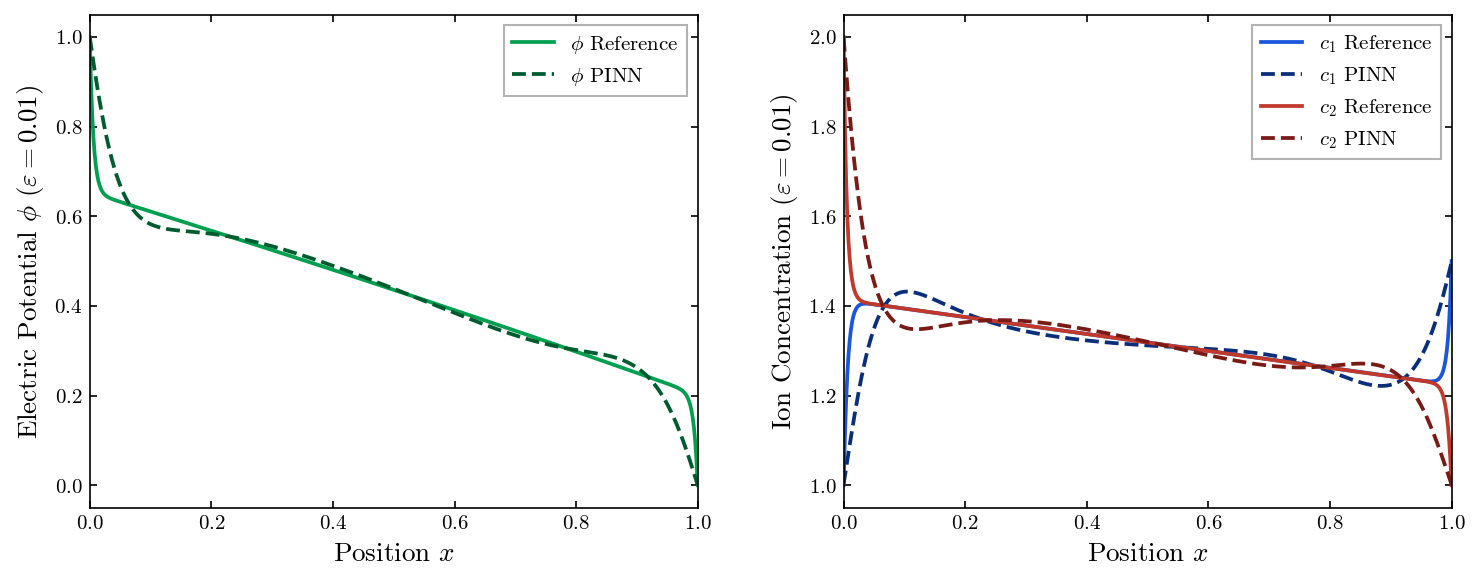

In [3]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from scipy.integrate import solve_bvp as scipy_bvp

# ============================================================
# Plot style: Computer Modern font, matching TikZ diagram
# ============================================================
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'axes.formatter.use_mathtext': True,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '0.7',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Colors matching the TikZ diagram palette
BLUE   = '#1a56db'
RED    = '#c0392b'
GREEN  = '#00a050'
BLUE_D = '#0b2e7a'   # darker blue for PINN dashed
RED_D  = '#7a1a15'   # darker red for PINN dashed
GREEN_D= '#005c2e'   # darker green for PINN dashed

# ============================================================
# Device configuration
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================
# Problem parameters
# ============================================================
V = 1.0
L1, L2 = 1.0, 2.0
R1, R2 = 1.5, 1.0
epsilon = 0.01

# ============================================================
# 1. Neural network
# ============================================================
class PINN_PNP(nn.Module):
    def __init__(self, layers=[1, 128, 128, 128, 3]):
        super(PINN_PNP, self).__init__()
        self.linears = nn.ModuleList()
        for i in range(len(layers)-1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = nn.Tanh()

    def forward(self, x):
        u = x
        for i, lin in enumerate(self.linears[:-1]):
            u = self.activation(lin(u))
        u = self.linears[-1](u)
        c1  = u[:, 0:1]
        c2  = u[:, 1:2]
        phi = u[:, 2:3]
        return c1, c2, phi

model = PINN_PNP().to(device)
print(model)

# ============================================================
# 2. Collocation points
# ============================================================
N_in = 200
N_b  = 50

x_in    = torch.linspace(0, 1, N_in, requires_grad=True).view(-1, 1).to(device)
x_left  = torch.zeros(N_b, 1, requires_grad=True).to(device)
x_right = torch.ones(N_b, 1, requires_grad=True).to(device)

# ============================================================
# 3. Loss function
# ============================================================
def compute_loss():
    losses = {}
    # Boundary
    c1_l, c2_l, phi_l = model(x_left)
    loss_b_left = (torch.mean((phi_l - V)**2) +
                   torch.mean((c1_l - L1)**2) +
                   torch.mean((c2_l - L2)**2))
    c1_r, c2_r, phi_r = model(x_right)
    loss_b_right = (torch.mean((phi_r - 0.0)**2) +
                    torch.mean((c1_r - R1)**2) +
                    torch.mean((c2_r - R2)**2))
    losses['b_left']  = loss_b_left
    losses['b_right'] = loss_b_right

    # Interior PDE residuals
    c1_pred, c2_pred, phi_pred = model(x_in)
    grad_phi  = grad(phi_pred, x_in, grad_outputs=torch.ones_like(phi_pred), create_graph=True)[0]
    grad_c1   = grad(c1_pred,  x_in, grad_outputs=torch.ones_like(c1_pred),  create_graph=True)[0]
    grad_c2   = grad(c2_pred,  x_in, grad_outputs=torch.ones_like(c2_pred),  create_graph=True)[0]
    grad2_phi = grad(grad_phi, x_in, grad_outputs=torch.ones_like(grad_phi), create_graph=True)[0]

    # Poisson: ε² φ'' = -(c1 - c2)
    residual_poisson = epsilon**2 * grad2_phi + (c1_pred - c2_pred)
    loss_p = torch.mean(residual_poisson**2)
    losses['p'] = loss_p

    # Nernst–Planck: d/dx(dc_k/dx + α_k c_k dφ/dx) = 0  =>  flux = const  =>  d(flux)/dx = 0
    residual_np1 = grad_c1 + c1_pred * grad_phi
    residual_np2 = grad_c2 - c2_pred * grad_phi
    grad_res1 = grad(residual_np1, x_in, grad_outputs=torch.ones_like(residual_np1), create_graph=True)[0]
    grad_res2 = grad(residual_np2, x_in, grad_outputs=torch.ones_like(residual_np2), create_graph=True)[0]
    loss_np1 = torch.mean(grad_res1**2)
    loss_np2 = torch.mean(grad_res2**2)
    losses['np1'] = loss_np1
    losses['np2'] = loss_np2

    loss_total = (1.0 * loss_p + 1.0 * loss_np1 + 1.0 * loss_np2 +
                  10.0 * loss_b_left + 10.0 * loss_b_right)
    losses['total'] = loss_total
    return losses

# ============================================================
# 4. Training
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9)
epochs = 50000
loss_history = {'total': [], 'p': [], 'np1': [], 'np2': [], 'b_left': [], 'b_right': []}

print("Starting PINN training...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    losses = compute_loss()
    loss = losses['total']
    loss.backward()
    optimizer.step()
    scheduler.step()

    for key in loss_history:
        loss_history[key].append(losses[key].item())

    if epoch % 2000 == 0:
        print(f"Epoch {epoch:5d} | Total: {loss.item():.3e} | "
              f"P: {losses['p'].item():.2e} | NP: {losses['np1'].item():.2e},{losses['np2'].item():.2e} | "
              f"B: {losses['b_left'].item():.2e},{losses['b_right'].item():.2e}")

# ============================================================
# 5. Reference solution via solve_bvp
# ============================================================
def compute_bvp_reference(eps, V, L1, L2, R1, R2, n_init=5000):
    """Solve the full PNP system with scipy solve_bvp."""
    c_L = np.sqrt(L1 * L2)
    c_R = np.sqrt(R1 * R2)
    phi_L = V + 0.5 * np.log(L1 / L2)
    phi_R = 0.5 * np.log(R1 / R2)
    M  = 2 * c_L
    T0 = 2 * (c_L - c_R)
    if abs(T0) > 1e-12:
        I0 = T0 * (phi_R - phi_L) / np.log(c_R / c_L)
    else:
        I0 = 2 * c_L * (phi_R - phi_L)
    J10 = (I0 + T0) / 2
    J20 = (T0 - I0) / 2

    l_param = (L2**0.25 - L1**0.25) / (L2**0.25 + L1**0.25)
    r_param = (R2**0.25 - R1**0.25) / (R2**0.25 + R1**0.25)
    N = 2 * c_R

    x_init = np.linspace(0, 1, n_init)
    c0 = c_L - T0 * x_init / 2
    if abs(T0) > 1e-12:
        phi0 = phi_L - (I0 / T0) * np.log(M) + (I0 / T0) * np.log(np.abs(M - T0 * x_init))
    else:
        phi0 = phi_L + I0 * x_init / (2 * c_L)

    xi  = x_init / eps
    u_L = l_param * np.exp(-np.sqrt(M) * np.minimum(xi, 100))
    rpL = (1 + u_L) / np.maximum(np.abs(1 - u_L), 1e-15)

    eta = (x_init - 1) / eps
    u_R = r_param * np.exp(np.sqrt(N) * np.maximum(eta, -100))
    rpR = (1 + u_R) / np.maximum(np.abs(1 - u_R), 1e-15)

    phi_guess = phi0 + 2 * np.log(np.abs(rpL)) + 2 * np.log(np.abs(rpR))
    c1_guess  = np.maximum(c0 + (c_L / rpL**2 - c_L) + (c_R / rpR**2 - c_R), 0.01)
    c2_guess  = np.maximum(c0 + (c_L * rpL**2 - c_L) + (c_R * rpR**2 - c_R), 0.01)

    y0 = np.zeros((6, n_init))
    y0[0] = phi_guess
    y0[1] = np.gradient(phi_guess, x_init)
    y0[2] = c1_guess
    y0[3] = c2_guess
    y0[4] = J10 * np.ones(n_init)
    y0[5] = J20 * np.ones(n_init)

    def pnp_ode(x, y):
        phi, E, c1, c2, J1, J2 = y
        return np.vstack([E, -(c1 - c2) / eps**2,
                          -c1 * E - J1, c2 * E - J2,
                          np.zeros_like(x), np.zeros_like(x)])

    def pnp_bc(ya, yb):
        return np.array([ya[0] - V, yb[0],
                         ya[2] - L1, yb[2] - R1,
                         ya[3] - L2, yb[3] - R2])

    sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
    assert sol.success, f"solve_bvp failed: {sol.message}"
    return sol

print("\nSolving reference BVP...")
sol_ref = compute_bvp_reference(epsilon, V, L1, L2, R1, R2)
print("BVP solved successfully.")

# ============================================================
# 6. Evaluation & Plotting
# ============================================================
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(0, 1, 500).view(-1, 1).to(device)
    c1_plot, c2_plot, phi_plot = model(x_plot)
    x_np   = x_plot.cpu().numpy().flatten()
    c1_np  = c1_plot.cpu().numpy().flatten()
    c2_np  = c2_plot.cpu().numpy().flatten()
    phi_np = phi_plot.cpu().numpy().flatten()

# Evaluate reference on the same x grid
y_ref  = sol_ref.sol(x_np)
phi_ref, c1_ref, c2_ref = y_ref[0], y_ref[2], y_ref[3]

# ============================================================
# 6a. Error metrics
# ============================================================
for name, u_nn, u_ex in [('phi', phi_np, phi_ref),
                          ('c1',  c1_np,  c1_ref),
                          ('c2',  c2_np,  c2_ref)]:
    err = np.abs(u_nn - u_ex)
    norm_ex  = np.sqrt(np.trapz(u_ex**2, x_np))
    norm_err = np.sqrt(np.trapz(err**2, x_np))
    rel_L2 = norm_err / max(norm_ex, 1e-16)
    Linf   = np.max(err)
    print(f"  {name:>3s}:  relative L2 = {rel_L2:.4e},  L_inf = {Linf:.4e}")
# ============================================================
# 6. Plotting
# ============================================================
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(0, 1, 500).view(-1, 1).to(device)
    c1_plot, c2_plot, phi_plot = model(x_plot)
    x_np   = x_plot.cpu().numpy().flatten()
    c1_np  = c1_plot.cpu().numpy().flatten()
    c2_np  = c2_plot.cpu().numpy().flatten()
    phi_np = phi_plot.cpu().numpy().flatten()

# Evaluate reference on the same x grid
y_ref  = sol_ref.sol(x_np)
phi_ref, c1_ref, c2_ref = y_ref[0], y_ref[2], y_ref[3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Left panel: Ion Concentrations ---
ax1.plot(x_np, phi_ref, color=GREEN,  linestyle='-',  label='$\\phi$ Reference')
ax1.plot(x_np, phi_np,  color=GREEN_D, linestyle='--', label='$\\phi$ PINN')
ax1.set_xlabel('Position $x$')
ax1.set_ylabel('Electric Potential $\\phi$ ($\\varepsilon=0.01$)')
ax1.set_xlim(0, 1)
ax1.legend(loc='best')

# --- Right panel: Electric Potential ---
ax2.plot(x_np, c1_ref, color=BLUE, linestyle='-',  label='$c_1$ Reference')
ax2.plot(x_np, c1_np,  color=BLUE_D, linestyle='--', label='$c_1$ PINN')
ax2.plot(x_np, c2_ref, color=RED,  linestyle='-',  label='$c_2$ Reference')
ax2.plot(x_np, c2_np,  color=RED_D, linestyle='--', label='$c_2$ PINN')
ax2.set_xlabel('Position $x$')
ax2.set_ylabel('Ion Concentration ($\\varepsilon=0.01$)')
ax2.set_xlim(0, 1)
ax2.legend(loc='best')

plt.tight_layout(w_pad=2.5)
plt.show()

Using device: cuda
PINN_PNP(
  (linears): ModuleList(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1-2): 2 x Linear(in_features=128, out_features=128, bias=True)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
  (activation): Tanh()
)
Starting PINN training...
Epoch     0 | Total: 8.871e+01 | P: 1.19e-02 | NP: 1.14e-03,3.33e-03 | B: 5.91e+00,2.95e+00
Epoch  2000 | Total: 8.748e-02 | P: 8.34e-02 | NP: 9.92e-04,8.73e-04 | B: 1.16e-04,1.04e-04
Epoch  4000 | Total: 6.087e-02 | P: 5.97e-02 | NP: 1.72e-04,1.29e-04 | B: 6.36e-05,2.65e-05
Epoch  6000 | Total: 5.112e-02 | P: 5.01e-02 | NP: 1.24e-04,1.77e-04 | B: 5.78e-05,1.12e-05
Epoch  8000 | Total: 4.499e-02 | P: 4.39e-02 | NP: 3.71e-04,1.92e-04 | B: 3.73e-05,1.36e-05
Epoch 10000 | Total: 4.131e-02 | P: 4.03e-02 | NP: 3.69e-04,2.10e-04 | B: 3.18e-05,1.10e-05
Epoch 12000 | Total: 9.813e-02 | P: 3.74e-02 | NP: 1.11e-02,4.10e-02 | B: 2.65e-04,6.01e-04
Epoch 14000 | Total: 3.708e-02 | P: 3.45e-02 | NP: 5.55e-04

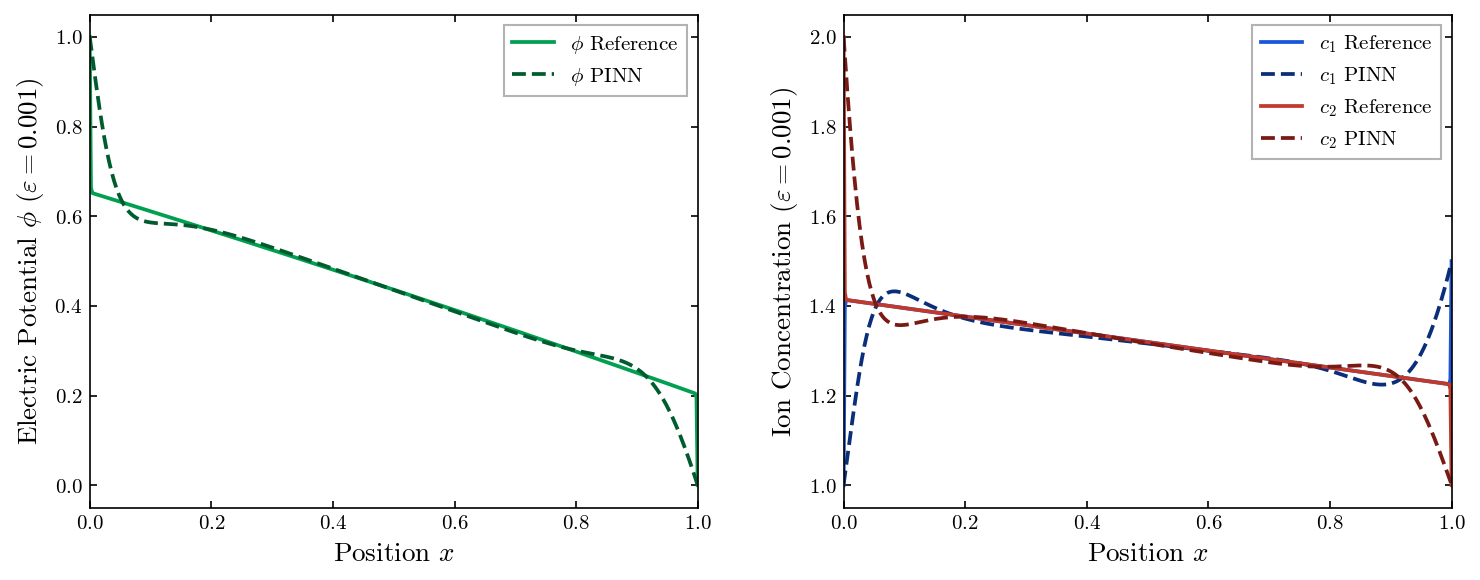

In [4]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from scipy.integrate import solve_bvp as scipy_bvp

# ============================================================
# Plot style: Computer Modern font, matching TikZ diagram
# ============================================================
plt.rcParams.update({
    'text.usetex': False,
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'font.serif': ['cmr10', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'axes.formatter.use_mathtext': True,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 1.8,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '0.7',
    'legend.fancybox': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Colors matching the TikZ diagram palette
BLUE   = '#1a56db'
RED    = '#c0392b'
GREEN  = '#00a050'
BLUE_D = '#0b2e7a'   # darker blue for PINN dashed
RED_D  = '#7a1a15'   # darker red for PINN dashed
GREEN_D= '#005c2e'   # darker green for PINN dashed

# ============================================================
# Device configuration
# ============================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ============================================================
# Problem parameters
# ============================================================
V = 1.0
L1, L2 = 1.0, 2.0
R1, R2 = 1.5, 1.0
epsilon = 0.001

# ============================================================
# 1. Neural network
# ============================================================
class PINN_PNP(nn.Module):
    def __init__(self, layers=[1, 128, 128, 128, 3]):
        super(PINN_PNP, self).__init__()
        self.linears = nn.ModuleList()
        for i in range(len(layers)-1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        self.activation = nn.Tanh()

    def forward(self, x):
        u = x
        for i, lin in enumerate(self.linears[:-1]):
            u = self.activation(lin(u))
        u = self.linears[-1](u)
        c1  = u[:, 0:1]
        c2  = u[:, 1:2]
        phi = u[:, 2:3]
        return c1, c2, phi

model = PINN_PNP().to(device)
print(model)

# ============================================================
# 2. Collocation points
# ============================================================
N_in = 200
N_b  = 50

x_in    = torch.linspace(0, 1, N_in, requires_grad=True).view(-1, 1).to(device)
x_left  = torch.zeros(N_b, 1, requires_grad=True).to(device)
x_right = torch.ones(N_b, 1, requires_grad=True).to(device)

# ============================================================
# 3. Loss function
# ============================================================
def compute_loss():
    losses = {}
    # Boundary
    c1_l, c2_l, phi_l = model(x_left)
    loss_b_left = (torch.mean((phi_l - V)**2) +
                   torch.mean((c1_l - L1)**2) +
                   torch.mean((c2_l - L2)**2))
    c1_r, c2_r, phi_r = model(x_right)
    loss_b_right = (torch.mean((phi_r - 0.0)**2) +
                    torch.mean((c1_r - R1)**2) +
                    torch.mean((c2_r - R2)**2))
    losses['b_left']  = loss_b_left
    losses['b_right'] = loss_b_right

    # Interior PDE residuals
    c1_pred, c2_pred, phi_pred = model(x_in)
    grad_phi  = grad(phi_pred, x_in, grad_outputs=torch.ones_like(phi_pred), create_graph=True)[0]
    grad_c1   = grad(c1_pred,  x_in, grad_outputs=torch.ones_like(c1_pred),  create_graph=True)[0]
    grad_c2   = grad(c2_pred,  x_in, grad_outputs=torch.ones_like(c2_pred),  create_graph=True)[0]
    grad2_phi = grad(grad_phi, x_in, grad_outputs=torch.ones_like(grad_phi), create_graph=True)[0]

    # Poisson: ε² φ'' = -(c1 - c2)
    residual_poisson = epsilon**2 * grad2_phi + (c1_pred - c2_pred)
    loss_p = torch.mean(residual_poisson**2)
    losses['p'] = loss_p

    # Nernst–Planck: d/dx(dc_k/dx + α_k c_k dφ/dx) = 0  =>  flux = const  =>  d(flux)/dx = 0
    residual_np1 = grad_c1 + c1_pred * grad_phi
    residual_np2 = grad_c2 - c2_pred * grad_phi
    grad_res1 = grad(residual_np1, x_in, grad_outputs=torch.ones_like(residual_np1), create_graph=True)[0]
    grad_res2 = grad(residual_np2, x_in, grad_outputs=torch.ones_like(residual_np2), create_graph=True)[0]
    loss_np1 = torch.mean(grad_res1**2)
    loss_np2 = torch.mean(grad_res2**2)
    losses['np1'] = loss_np1
    losses['np2'] = loss_np2

    loss_total = (1.0 * loss_p + 1.0 * loss_np1 + 1.0 * loss_np2 +
                  10.0 * loss_b_left + 10.0 * loss_b_right)
    losses['total'] = loss_total
    return losses

# ============================================================
# 4. Training
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.9)
epochs = 50000
loss_history = {'total': [], 'p': [], 'np1': [], 'np2': [], 'b_left': [], 'b_right': []}

print("Starting PINN training...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    losses = compute_loss()
    loss = losses['total']
    loss.backward()
    optimizer.step()
    scheduler.step()

    for key in loss_history:
        loss_history[key].append(losses[key].item())

    if epoch % 2000 == 0:
        print(f"Epoch {epoch:5d} | Total: {loss.item():.3e} | "
              f"P: {losses['p'].item():.2e} | NP: {losses['np1'].item():.2e},{losses['np2'].item():.2e} | "
              f"B: {losses['b_left'].item():.2e},{losses['b_right'].item():.2e}")

# ============================================================
# 5. Reference solution via solve_bvp
# ============================================================
def compute_bvp_reference(eps, V, L1, L2, R1, R2, n_init=5000):
    """Solve the full PNP system with scipy solve_bvp."""
    c_L = np.sqrt(L1 * L2)
    c_R = np.sqrt(R1 * R2)
    phi_L = V + 0.5 * np.log(L1 / L2)
    phi_R = 0.5 * np.log(R1 / R2)
    M  = 2 * c_L
    T0 = 2 * (c_L - c_R)
    if abs(T0) > 1e-12:
        I0 = T0 * (phi_R - phi_L) / np.log(c_R / c_L)
    else:
        I0 = 2 * c_L * (phi_R - phi_L)
    J10 = (I0 + T0) / 2
    J20 = (T0 - I0) / 2

    l_param = (L2**0.25 - L1**0.25) / (L2**0.25 + L1**0.25)
    r_param = (R2**0.25 - R1**0.25) / (R2**0.25 + R1**0.25)
    N = 2 * c_R

    x_init = np.linspace(0, 1, n_init)
    c0 = c_L - T0 * x_init / 2
    if abs(T0) > 1e-12:
        phi0 = phi_L - (I0 / T0) * np.log(M) + (I0 / T0) * np.log(np.abs(M - T0 * x_init))
    else:
        phi0 = phi_L + I0 * x_init / (2 * c_L)

    xi  = x_init / eps
    u_L = l_param * np.exp(-np.sqrt(M) * np.minimum(xi, 100))
    rpL = (1 + u_L) / np.maximum(np.abs(1 - u_L), 1e-15)

    eta = (x_init - 1) / eps
    u_R = r_param * np.exp(np.sqrt(N) * np.maximum(eta, -100))
    rpR = (1 + u_R) / np.maximum(np.abs(1 - u_R), 1e-15)

    phi_guess = phi0 + 2 * np.log(np.abs(rpL)) + 2 * np.log(np.abs(rpR))
    c1_guess  = np.maximum(c0 + (c_L / rpL**2 - c_L) + (c_R / rpR**2 - c_R), 0.01)
    c2_guess  = np.maximum(c0 + (c_L * rpL**2 - c_L) + (c_R * rpR**2 - c_R), 0.01)

    y0 = np.zeros((6, n_init))
    y0[0] = phi_guess
    y0[1] = np.gradient(phi_guess, x_init)
    y0[2] = c1_guess
    y0[3] = c2_guess
    y0[4] = J10 * np.ones(n_init)
    y0[5] = J20 * np.ones(n_init)

    def pnp_ode(x, y):
        phi, E, c1, c2, J1, J2 = y
        return np.vstack([E, -(c1 - c2) / eps**2,
                          -c1 * E - J1, c2 * E - J2,
                          np.zeros_like(x), np.zeros_like(x)])

    def pnp_bc(ya, yb):
        return np.array([ya[0] - V, yb[0],
                         ya[2] - L1, yb[2] - R1,
                         ya[3] - L2, yb[3] - R2])

    sol = scipy_bvp(pnp_ode, pnp_bc, x_init, y0, tol=1e-8, max_nodes=100000)
    assert sol.success, f"solve_bvp failed: {sol.message}"
    return sol

print("\nSolving reference BVP...")
sol_ref = compute_bvp_reference(epsilon, V, L1, L2, R1, R2)
print("BVP solved successfully.")

# ============================================================
# 6. Evaluation & Plotting
# ============================================================
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(0, 1, 500).view(-1, 1).to(device)
    c1_plot, c2_plot, phi_plot = model(x_plot)
    x_np   = x_plot.cpu().numpy().flatten()
    c1_np  = c1_plot.cpu().numpy().flatten()
    c2_np  = c2_plot.cpu().numpy().flatten()
    phi_np = phi_plot.cpu().numpy().flatten()

# Evaluate reference on the same x grid
y_ref  = sol_ref.sol(x_np)
phi_ref, c1_ref, c2_ref = y_ref[0], y_ref[2], y_ref[3]

# ============================================================
# 6a. Error metrics
# ============================================================
for name, u_nn, u_ex in [('phi', phi_np, phi_ref),
                          ('c1',  c1_np,  c1_ref),
                          ('c2',  c2_np,  c2_ref)]:
    err = np.abs(u_nn - u_ex)
    norm_ex  = np.sqrt(np.trapz(u_ex**2, x_np))
    norm_err = np.sqrt(np.trapz(err**2, x_np))
    rel_L2 = norm_err / max(norm_ex, 1e-16)
    Linf   = np.max(err)
    print(f"  {name:>3s}:  relative L2 = {rel_L2:.4e},  L_inf = {Linf:.4e}")
# ============================================================
# 6. Plotting
# ============================================================
model.eval()
with torch.no_grad():
    x_plot = torch.linspace(0, 1, 500).view(-1, 1).to(device)
    c1_plot, c2_plot, phi_plot = model(x_plot)
    x_np   = x_plot.cpu().numpy().flatten()
    c1_np  = c1_plot.cpu().numpy().flatten()
    c2_np  = c2_plot.cpu().numpy().flatten()
    phi_np = phi_plot.cpu().numpy().flatten()

# Evaluate reference on the same x grid
y_ref  = sol_ref.sol(x_np)
phi_ref, c1_ref, c2_ref = y_ref[0], y_ref[2], y_ref[3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Left panel: Ion Concentrations ---
ax1.plot(x_np, phi_ref, color=GREEN,  linestyle='-',  label='$\\phi$ Reference')
ax1.plot(x_np, phi_np,  color=GREEN_D, linestyle='--', label='$\\phi$ PINN')
ax1.set_xlabel('Position $x$')
ax1.set_ylabel('Electric Potential $\\phi$ ($\\varepsilon=0.001$)')
ax1.set_xlim(0, 1)
ax1.legend(loc='best')

# --- Right panel: Electric Potential ---
ax2.plot(x_np, c1_ref, color=BLUE, linestyle='-',  label='$c_1$ Reference')
ax2.plot(x_np, c1_np,  color=BLUE_D, linestyle='--', label='$c_1$ PINN')
ax2.plot(x_np, c2_ref, color=RED,  linestyle='-',  label='$c_2$ Reference')
ax2.plot(x_np, c2_np,  color=RED_D, linestyle='--', label='$c_2$ PINN')
ax2.set_xlabel('Position $x$')
ax2.set_ylabel('Ion Concentration ($\\varepsilon=0.001$)')
ax2.set_xlim(0, 1)
ax2.legend(loc='best')

plt.tight_layout(w_pad=2.5)
plt.show()